# Truncated-SVD regularization of wavefront reconstruction

**Scientific question.** A Shack–Hartmann interaction matrix has a spread of
singular values; the smallest ones correspond to poorly sensed actuator
combinations. How does the truncation threshold `rcond` trade recovered signal
against amplified measurement noise when reconstructing a known deformable-
mirror command from noisy slopes?

Calibration, the SVD, and the truncated-SVD reconstructor are all installed
`shwfs_ao` APIs.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.calibration import (
    DmActuatorProbeBasis,
    TsvdReconstructor,
    calibrate_interaction_matrix,
    interaction_diagnostics,
)
from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.core.types import DmCommandVector
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.dm import DMConfig, build_native_deformable_mirror
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

SEED = 20240517
TELESCOPE_DIAMETER_M = 1.0
WFS_WAVELENGTH_M = 700e-9
RCOND_VALUES = (3e-1, 1e-1, 3e-2, 1e-2, 3e-3, 1e-3)

## Configuration

In [2]:
geometry = build_shack_hartmann_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(60, 60),
    n_lenslets_across=6,
    min_fill_fraction=0.4,
)
optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
sensor = build_detector_shack_hartmann_sensor(
    geometry,
    optics,
    DetectorConfig(photons_per_subap_frame=4e3),
    wfs_wavelength_m=WFS_WAVELENGTH_M,
    random_streams=NamedRandomStreams(SEED),
)
mirror = build_native_deformable_mirror(
    geometry.x_m,
    geometry.y_m,
    geometry.pupil_mask,
    DMConfig(
        telescope_diameter_m=TELESCOPE_DIAMETER_M,
        n_actuators_across=7,
        coupling_width_pitch=0.35,
        stroke_limit_nm=20000.0,
    ),
)
interaction = calibrate_interaction_matrix(
    DmActuatorProbeBasis(mirror),
    sensor,
    amplitude_m=25e-9,
    random_streams=NamedRandomStreams(SEED).scoped("calibration-probe"),
    include_noise=False,
)
diagnostics = interaction_diagnostics(
    np.asarray(interaction.matrix), np.asarray(interaction.row_valid)
)

## Simulation call

In [3]:
rng = np.random.default_rng(SEED)
true_command = 80e-9 * rng.standard_normal(mirror.n_actuators)
target_opd_m = mirror.opd_from_commands(
    DmCommandVector(
        values_opd_m=true_command,
        actuator_ids=mirror.actuator_ids,
        command_unit="m_opd_equivalent",
    )
).correction_opd_m
noisy = sensor.measure(
    target_opd_m, random_streams=NamedRandomStreams(SEED), include_noise=True
)

def recover(rcond):
    reconstructor = TsvdReconstructor(
        interaction, rcond=rcond, min_valid_fraction=0.5, min_rank=1
    )
    estimate = reconstructor.reconstruct(noisy.vector)
    recovered = np.asarray(estimate.delta_coordinates_opd_m, dtype=float)
    command_error = np.sqrt(np.mean((recovered - true_command) ** 2))
    return int(estimate.kept_modes), float(command_error)

results = {rcond: recover(rcond) for rcond in RCOND_VALUES}

## Diagnostic table

In [4]:
table = pd.DataFrame(
    [
        (rcond, results[rcond][0], results[rcond][1] * 1e9)
        for rcond in RCOND_VALUES
    ],
    columns=["rcond", "kept modes", "command RMS error (nm)"],
)
best = min(RCOND_VALUES, key=lambda r: results[r][1])
print(f"best rcond for this noise level: {best} "
      f"({results[best][0]} modes, {results[best][1] * 1e9:.1f} nm error)")
table

best rcond for this noise level: 0.3 (29 modes, 8.6 nm error)


,rcond,kept modes,command RMS error (nm)
0,0.300,29,8.578516
1,0.100,29,8.578516
2,0.030,29,8.578516
3,0.010,29,8.578516
4,0.003,29,8.578516
5,0.001,29,8.578516


## Plot

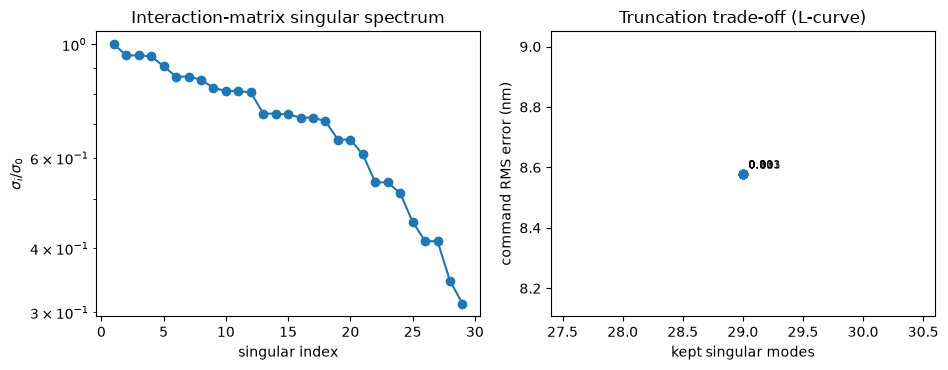

In [5]:
singular = np.asarray(diagnostics.singular_values, dtype=float)
normalized = singular / singular[0]
figure, (left, right) = plt.subplots(1, 2, figsize=(9.6, 3.8))
left.semilogy(np.arange(1, normalized.size + 1), normalized, "o-")
left.set_xlabel("singular index")
left.set_ylabel(r"$\sigma_i / \sigma_0$")
left.set_title("Interaction-matrix singular spectrum")
kept = [results[r][0] for r in RCOND_VALUES]
errors_nm = [results[r][1] * 1e9 for r in RCOND_VALUES]
right.plot(kept, errors_nm, "o-")
for rcond, k, e in zip(RCOND_VALUES, kept, errors_nm):
    right.annotate(f"{rcond:g}", (k, e), textcoords="offset points", xytext=(4, 4),
                   fontsize=8)
right.set_xlabel("kept singular modes")
right.set_ylabel("command RMS error (nm)")
right.set_title("Truncation trade-off (L-curve)")
figure.tight_layout()
plt.show()

## Interpretation

The singular spectrum falls off smoothly, and the reconstruction error traces a
classic L-curve against the number of retained modes: keeping too few modes
discards recoverable signal, while keeping too many amplifies noise through the
smallest singular values. The best `rcond` sits at the elbow, where the sensed
subspace is captured but the noisy tail is suppressed. This is why the closed-
loop controller uses a regularized reconstructor rather than a raw pseudo-
inverse.

## Limitations

- One noise realization determines the elbow; the optimum shifts with photon
  flux and would ideally be averaged.
- A single random command is reconstructed; a full evaluation would scan a
  mode basis.
- `min_rank` and `min_valid_fraction` are fixed to conservative defaults.